## Dagshub/MLFlow initialization

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import dagshub
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

In [5]:
# Init dagshub
dagshub.init(
    repo_owner='lkhiz23',
    repo_name='House-Prices',
    mlflow=True
)
mlflow.set_experiment("house-prices")

Accessing as lkhiz23

Initialized MLflow to track repo "lkhiz23/House-Prices"

Repository lkhiz23/House-Prices initialized!

<Experiment: artifact_location='mlflow-artifacts:/f9e1c8b09b064383930bd71ebfb93255', creation_time=1775695934039, experiment_id='0', last_update_time=1775695934039, lifecycle_stage='active', name='house-prices', tags={}>

## Exploratory Data Analysis (EDA)

In [62]:
# Load data
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(train, test_size=0.2, random_state=42)
print(f"train_df: {train_df.shape}, test_df: {test_df.shape}")

train_df: (1168, 81), test_df: (292, 81)


In [63]:
# Numerical vs Categorical columns
num_cols = train_df.select_dtypes(include='number').columns.tolist()
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Numeric columns: 38
Categorical columns: 43


In [64]:
# Missing values
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = ((missing / len(train_df)) * 100).round(2)
missing_df = pd.DataFrame({"Missing count": missing, "Missing %": missing_pct})
print(missing_df)

              Missing count  Missing %
PoolQC                 1162      99.49
MiscFeature            1122      96.06
Alley                  1094      93.66
Fence                   935      80.05
MasVnrType              683      58.48
FireplaceQu             547      46.83
LotFrontage             217      18.58
GarageType               64       5.48
GarageYrBlt              64       5.48
GarageFinish             64       5.48
GarageQual               64       5.48
GarageCond               64       5.48
BsmtFinType1             28       2.40
BsmtFinType2             28       2.40
BsmtExposure             28       2.40
BsmtCond                 28       2.40
BsmtQual                 28       2.40
MasVnrArea                6       0.51
Electrical                1       0.09


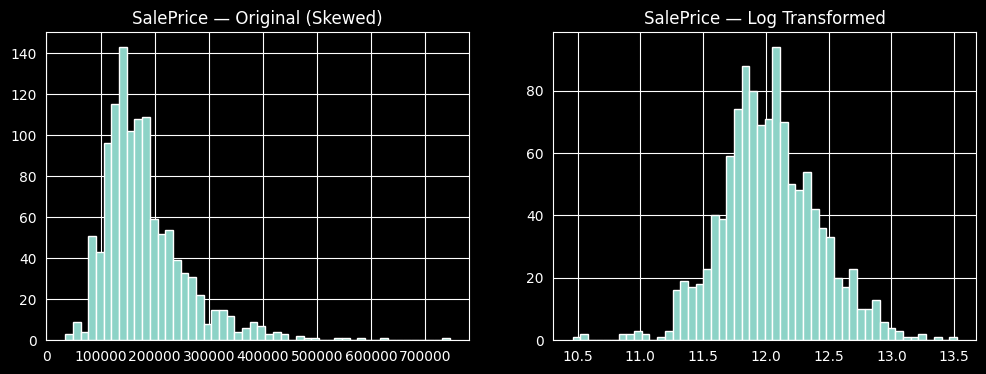

In [65]:
# Target distribution
import os
os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['SalePrice'], bins=50)
axes[0].set_title('SalePrice — Original (Skewed)')
axes[1].hist(np.log1p(train_df['SalePrice']), bins=50)
axes[1].set_title('SalePrice — Log Transformed')
plt.savefig('images/saleprice_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [66]:
# Number of houses in the desired range
total = len(train_df)
print("ფასების განაწილება:")
print(f"< 100k:   {(train_df['SalePrice'] < 100000).sum()} სახლი ({(train_df['SalePrice'] < 100000).sum()/total*100:.1f}%)")
print(f"100-200k: {((train_df['SalePrice'] >= 100000) & (train_df['SalePrice'] < 200000)).sum()} სახლი ({((train_df['SalePrice'] >= 100000) & (train_df['SalePrice'] < 200000)).sum()/total*100:.1f}%)")
print(f"200-300k: {((train_df['SalePrice'] >= 200000) & (train_df['SalePrice'] < 300000)).sum()} სახლი ({((train_df['SalePrice'] >= 200000) & (train_df['SalePrice'] < 300000)).sum()/total*100:.1f}%)")
print(f"300-500k: {((train_df['SalePrice'] >= 300000) & (train_df['SalePrice'] < 500000)).sum()} სახლი ({((train_df['SalePrice'] >= 300000) & (train_df['SalePrice'] < 500000)).sum()/total*100:.1f}%)")
print(f"> 500k:   {(train_df['SalePrice'] >= 500000).sum()} სახლი ({(train_df['SalePrice'] >= 500000).sum()/total*100:.1f}%)")
print(f"> 700k:   {(train_df['SalePrice'] >= 700000).sum()} სახლი ({(train_df['SalePrice'] >= 700000).sum()/total*100:.1f}%)")

ფასების განაწილება:
< 100k:   88 სახლი (7.5%)
100-200k: 727 სახლი (62.2%)
200-300k: 262 სახლი (22.4%)
300-500k: 85 სახლი (7.3%)
> 500k:   6 სახლი (0.5%)
> 700k:   1 სახლი (0.1%)


In [67]:
# Statistics
print(f"საშუალო:   ${train_df['SalePrice'].mean():,.0f}")
print(f"მედიანა:   ${train_df['SalePrice'].median():,.0f}")
print(f"მაქსიმუმი: ${train_df['SalePrice'].max():,.0f}")
print(f"მინიმუმი:  ${train_df['SalePrice'].min():,.0f}")
print(f"\nSkewness: {train_df['SalePrice'].skew():.4f}")
print(f"Log Skewness: {np.log1p(train_df['SalePrice']).skew():.4f}")

საშუალო:   $181,442
მედიანა:   $165,000
მაქსიმუმი: $745,000
მინიმუმი:  $34,900

Skewness: 1.7431
Log Skewness: 0.1249


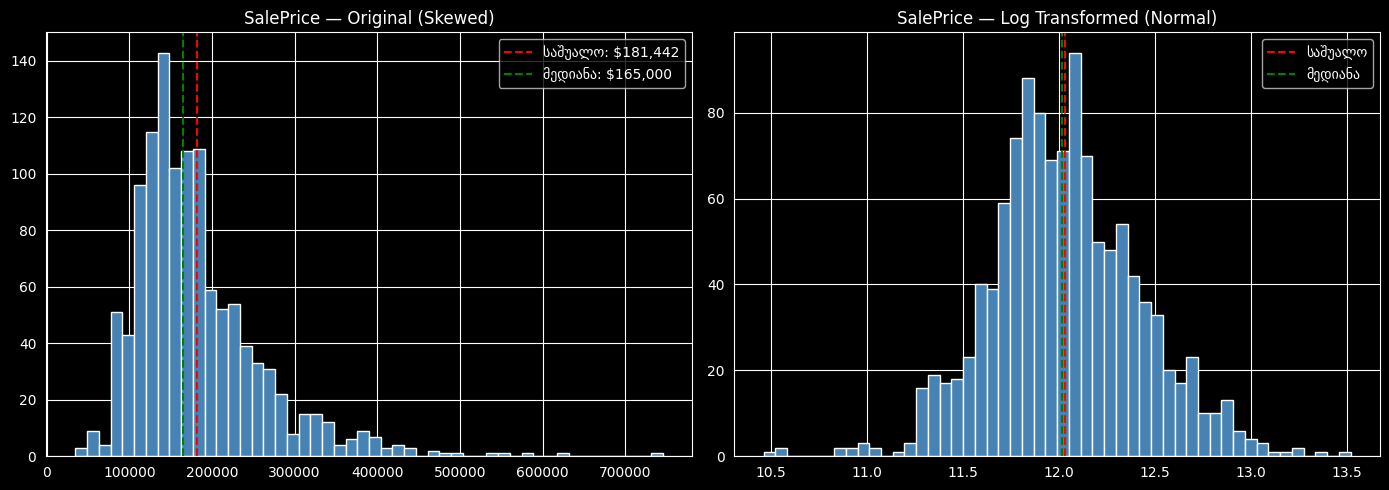

In [68]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train_df['SalePrice'].mean(), color='red', linestyle='--', label=f"საშუალო: ${train_df['SalePrice'].mean():,.0f}")
axes[0].axvline(train_df['SalePrice'].median(), color='green', linestyle='--', label=f"მედიანა: ${train_df['SalePrice'].median():,.0f}")
axes[0].set_title('SalePrice — Original (Skewed)')
axes[0].legend()

axes[1].hist(np.log1p(train_df['SalePrice']), bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(np.log1p(train_df['SalePrice']).mean(), color='red', linestyle='--', label='საშუალო')
axes[1].axvline(np.log1p(train_df['SalePrice']).median(), color='green', linestyle='--', label='მედიანა')
axes[1].set_title('SalePrice — Log Transformed (Normal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/saleprice_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [69]:
# Correlation with SalePrice
corr = train_df[num_cols].corr()['SalePrice'].sort_values(ascending=False)
print("Top 10:")
print(corr.head(10).round(2))
print("\nBottom 5:")
print(corr.tail(5).round(2))

Top 10:
SalePrice       1.00
OverallQual     0.79
GrLivArea       0.70
GarageCars      0.64
GarageArea      0.62
TotalBsmtSF     0.60
1stFlrSF        0.59
FullBath        0.55
TotRmsAbvGrd    0.52
YearBuilt       0.52
Name: SalePrice, dtype: float64

Bottom 5:
BsmtHalfBath    -0.05
OverallCond     -0.07
MSSubClass      -0.09
KitchenAbvGr    -0.14
EnclosedPorch   -0.15
Name: SalePrice, dtype: float64


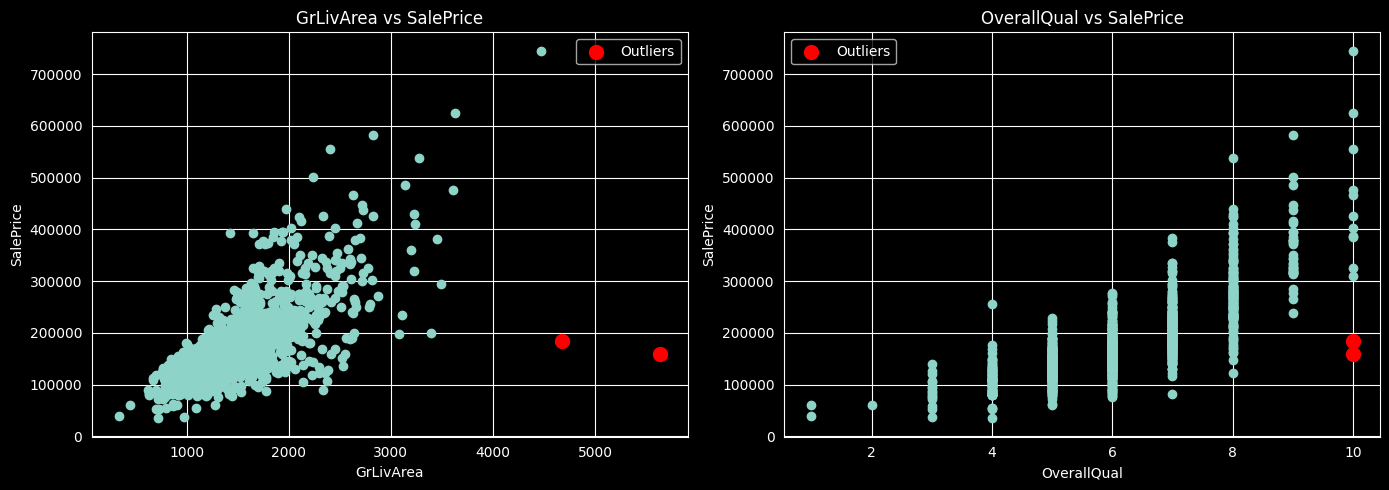

In [70]:
# Outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
normal = train_df.drop(outliers.index)

# GrLivArea plot
axes[0].scatter(normal['GrLivArea'], normal['SalePrice'])
axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                color='red', s=100, zorder=5, label='Outliers')
axes[0].set_title('GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].legend()

# OverallQual plot
axes[1].scatter(normal['OverallQual'], normal['SalePrice'])
axes[1].scatter(outliers['OverallQual'], outliers['SalePrice'],
                color='red', s=100, zorder=5, label='Outliers')
axes[1].set_title('OverallQual vs SalePrice')
axes[1].set_xlabel('OverallQual')
axes[1].set_ylabel('SalePrice')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/outliers.png', bbox_inches='tight', dpi=150)
plt.show()

In [71]:
# Check if above outliers are the same
outliers_grliv = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
print("GrLivArea outliers:")
print(outliers_grliv[['GrLivArea', 'OverallQual', 'SalePrice']])

GrLivArea outliers:
      GrLivArea  OverallQual  SalePrice
523        4676           10     184750
1298       5642           10     160000


## Data Cleaning

In [72]:
# Target variable — log transform
y = np.log1p(train_df['SalePrice'])
X = train_df.drop('SalePrice', axis=1)

# Test set
y_test_final = np.log1p(test_df['SalePrice'])
X_test_final = test_df.drop('SalePrice', axis=1)

print(f"X shape: {X.shape}")
print(f"X_test shape: {X_test_final.shape}")

X shape: (1168, 80)
X_test shape: (292, 80)


In [73]:
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numeric: {len(numeric_cols)}")
print(f"Categorical: {len(categorical_cols)}")

Numeric: 37
Categorical: 43


In [74]:
# high missing columns
high_missing = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# NaN = "არ აქვს" columns
none_cols = ['FireplaceQu', 'MasVnrType', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2']

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Strategy 1: drop 80%+ missing + median imputation + constant + OHE
drop_cols_s1 = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
X_s1 = X.drop(columns=drop_cols_s1)
X_test_s1 = X_test_final.drop(columns=drop_cols_s1)

num_cols_s1 = X_s1.select_dtypes(include='number').columns.tolist()
cat_cols_s1 = X_s1.select_dtypes(include='object').columns.tolist()

# none_cols in categorical — NaN → "None"
none_cols = ['FireplaceQu', 'MasVnrType', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2']

# pipeline
numeric_transformer_s1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s1 = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s1 = ColumnTransformer([
    ('num', numeric_transformer_s1, num_cols_s1),
    ('cat', categorical_transformer_s1, cat_cols_s1)
])

pipeline_s1 = Pipeline([
    ('preprocessor', preprocessor_s1),
    ('model', LinearRegression())
])

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_s1 = cross_val_score(pipeline_s1, X_s1, y,
                         cv=kf,
                         scoring='neg_root_mean_squared_error')
cv_rmse_s1 = -scores_s1.mean()
cv_std_s1 = scores_s1.std()

print(f"Strategy 1 CV RMSE: {cv_rmse_s1:.4f} ± {cv_std_s1:.4f}")

Strategy 1 CV RMSE: 0.1644 ± 0.0240


In [55]:
with mlflow.start_run(run_name="cleaning_s1_drop80_median_ohe"):
    mlflow.log_param("outliers_removed", False)
    mlflow.log_param("drop_threshold", "80%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "None_constant")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s1)
    mlflow.log_metric("cv_std", cv_std_s1)

In [76]:
# Strategy 2: drop 45%+ missing + median imputation + most_frequent + OHE
drop_cols_s2 = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']

X_s2 = X.drop(columns=drop_cols_s2)
X_test_s2 = X_test_final.drop(columns=drop_cols_s2)

num_cols_s2 = X_s2.select_dtypes(include='number').columns.tolist()
cat_cols_s2 = X_s2.select_dtypes(include='object').columns.tolist()

numeric_transformer_s2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s2 = ColumnTransformer([
    ('num', numeric_transformer_s2, num_cols_s2),
    ('cat', categorical_transformer_s2, cat_cols_s2)
])

pipeline_s2 = Pipeline([
    ('preprocessor', preprocessor_s2),
    ('model', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_s2 = cross_val_score(pipeline_s2, X_s2, y,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s2 = -scores_s2.mean()
cv_std_s2 = scores_s2.std()

print(f"Strategy 2 CV RMSE: {cv_rmse_s2:.4f} ± {cv_std_s2:.4f}")

Strategy 2 CV RMSE: 0.1624 ± 0.0229


In [57]:
with mlflow.start_run(run_name="cleaning_s2_drop45_median_ohe"):
    mlflow.log_param("outliers_removed", False)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s2)
    mlflow.log_metric("cv_std", cv_std_s2)

In [77]:
# Strategy 3: remove outliers + drop 80%+ missing + median imputation + constant + OHE
outlier_idx = train_df[(train_df['GrLivArea'] > 4000) &
                        (train_df['SalePrice'] < 300000)].index

X_s3 = X.drop(index=outlier_idx).drop(columns=drop_cols_s1)
y_s3 = y.drop(index=outlier_idx)

num_cols_s3 = X_s3.select_dtypes(include='number').columns.tolist()
cat_cols_s3 = X_s3.select_dtypes(include='object').columns.tolist()

numeric_transformer_s3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s3 = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s3 = ColumnTransformer([
    ('num', numeric_transformer_s3, num_cols_s3),
    ('cat', categorical_transformer_s3, cat_cols_s3)
])

pipeline_s3 = Pipeline([
    ('preprocessor', preprocessor_s3),
    ('model', LinearRegression())
])

scores_s3 = cross_val_score(pipeline_s3, X_s3, y_s3,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s3 = -scores_s3.mean()
cv_std_s3 = scores_s3.std()

print(f"Strategy 3 CV RMSE: {cv_rmse_s3:.4f} ± {cv_std_s3:.4f}")

Strategy 3 CV RMSE: 0.1364 ± 0.0149


In [59]:
with mlflow.start_run(run_name="cleaning_s3_drop80_median_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "80%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "None_constant")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s3)
    mlflow.log_metric("cv_std", cv_std_s3)

In [78]:
# Strategy 4: remove outliers + drop 45%+ missing + median imputation + most_frequent + OHE
X_s4 = X.drop(index=outlier_idx).drop(columns=drop_cols_s2)
y_s4 = y.drop(index=outlier_idx)

num_cols_s4 = X_s4.select_dtypes(include='number').columns.tolist()
cat_cols_s4 = X_s4.select_dtypes(include='object').columns.tolist()

numeric_transformer_s4 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s4 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s4 = ColumnTransformer([
    ('num', numeric_transformer_s4, num_cols_s4),
    ('cat', categorical_transformer_s4, cat_cols_s4)
])

pipeline_s4 = Pipeline([
    ('preprocessor', preprocessor_s4),
    ('model', LinearRegression())
])

scores_s4 = cross_val_score(pipeline_s4, X_s4, y_s4,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s4 = -scores_s4.mean()
cv_std_s4 = scores_s4.std()

print(f"Strategy 4 CV RMSE: {cv_rmse_s4:.4f} ± {cv_std_s4:.4f}")

Strategy 4 CV RMSE: 0.1352 ± 0.0158


In [61]:
with mlflow.start_run(run_name="cleaning_s4_drop45_median_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s4)
    mlflow.log_metric("cv_std", cv_std_s4)

In [79]:
# Strategy 5: remove outliers + drop 45%+ + mean imputation + most_frequent + OHE
X_s5 = X.drop(index=outlier_idx).drop(columns=drop_cols_s2)
y_s5 = y.drop(index=outlier_idx)

num_cols_s5 = X_s5.select_dtypes(include='number').columns.tolist()
cat_cols_s5 = X_s5.select_dtypes(include='object').columns.tolist()

numeric_transformer_s5 = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer_s5 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s5 = ColumnTransformer([
    ('num', numeric_transformer_s5, num_cols_s5),
    ('cat', categorical_transformer_s5, cat_cols_s5)
])

pipeline_s5 = Pipeline([
    ('preprocessor', preprocessor_s5),
    ('model', LinearRegression())
])

scores_s5 = cross_val_score(pipeline_s5, X_s5, y_s5,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s5 = -scores_s5.mean()
cv_std_s5 = scores_s5.std()

print(f"Strategy 5 CV RMSE: {cv_rmse_s5:.4f} ± {cv_std_s5:.4f}")

Strategy 5 CV RMSE: 0.1352 ± 0.0158


In [64]:
with mlflow.start_run(run_name="cleaning_s5_drop45_mean_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "mean")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("cv_rmse", cv_rmse_s5)
    mlflow.log_metric("cv_std", cv_std_s5)

In [80]:
# Strategy 6: remove outliers + drop 45%+ + median imputation + most_frequent + Full Ordinal + OHE
from sklearn.preprocessing import OrdinalEncoder

X_s6 = X.drop(index=outlier_idx).drop(columns=drop_cols_s2)
y_s6 = y.drop(index=outlier_idx)

# ordinal columns
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond']
ordinal_categories = [['Po', 'Fa', 'TA', 'Gd', 'Ex']] * len(ordinal_cols)

extra_ordinal_cols = ['BsmtExposure', 'GarageFinish', 'Functional', 'Electrical']
extra_ordinal_categories = [
    ['No', 'Mn', 'Av', 'Gd'],
    ['Unf', 'RFn', 'Fin'],
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr']
]

bsmt_fin_cols = ['BsmtFinType1', 'BsmtFinType2']
bsmt_fin_categories = [['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']] * 2

all_ordinal_cols = ordinal_cols + extra_ordinal_cols + bsmt_fin_cols
all_ordinal_categories = ordinal_categories + extra_ordinal_categories + bsmt_fin_categories

# remaining categorical columns
remaining_cat_cols = [col for col in X_s6.select_dtypes(include='object').columns.tolist()
                      if col not in all_ordinal_cols]
num_cols_s6 = X_s6.select_dtypes(include='number').columns.tolist()

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='TA')),
    ('encoder', OrdinalEncoder(categories=all_ordinal_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

numeric_transformer_s6 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s6 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s6 = ColumnTransformer([
    ('num', numeric_transformer_s6, num_cols_s6),
    ('ordinal', ordinal_transformer, all_ordinal_cols),
    ('cat', categorical_transformer_s6, remaining_cat_cols)
])

pipeline_s6 = Pipeline([
    ('preprocessor', preprocessor_s6),
    ('model', LinearRegression())
])

scores_s6 = cross_val_score(pipeline_s6, X_s6, y_s6,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s6 = -scores_s6.mean()
cv_std_s6 = scores_s6.std()

print(f"Strategy 6 CV RMSE: {cv_rmse_s6:.4f} ± {cv_std_s6:.4f}")

Strategy 6 CV RMSE: 0.1296 ± 0.0109


In [72]:
with mlflow.start_run(run_name="cleaning_s6_drop45_median_ordinal_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "ordinal+ohe")
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("cv_rmse", cv_rmse_s6)
    mlflow.log_metric("cv_std", cv_std_s6)

## Feature Engineering

In [81]:
# Correlation of numeric features with SalePrice
corr = train_df[num_cols].corr()['SalePrice'].sort_values(ascending=False)
print("Top 15:")
print(corr.head(15).round(2))
print("\nBottom 10:")
print(corr.tail(10).round(2))

Top 15:
SalePrice       1.00
OverallQual     0.79
GrLivArea       0.70
GarageCars      0.64
GarageArea      0.62
TotalBsmtSF     0.60
1stFlrSF        0.59
FullBath        0.55
TotRmsAbvGrd    0.52
YearBuilt       0.52
YearRemodAdd    0.51
GarageYrBlt     0.48
MasVnrArea      0.46
Fireplaces      0.46
BsmtFinSF1      0.36
Name: SalePrice, dtype: float64

Bottom 10:
BsmtFinSF2      -0.01
YrSold          -0.01
LowQualFinSF    -0.01
Id              -0.02
MiscVal         -0.02
BsmtHalfBath    -0.05
OverallCond     -0.07
MSSubClass      -0.09
KitchenAbvGr    -0.14
EnclosedPorch   -0.15
Name: SalePrice, dtype: float64


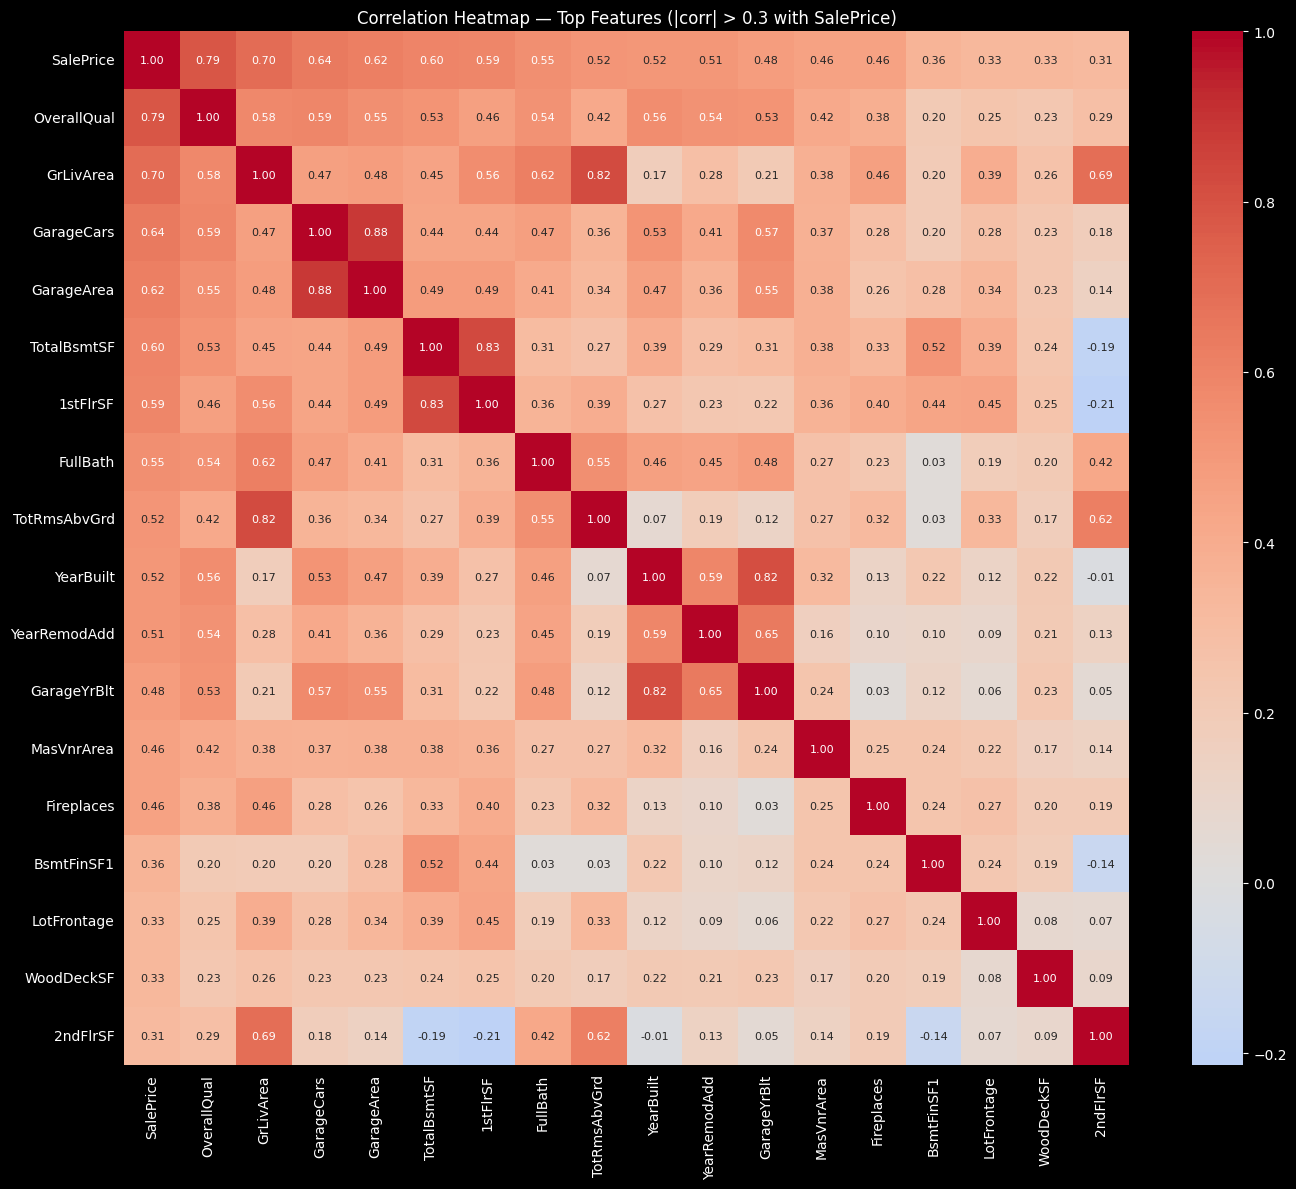

In [82]:
# Top correlated features with SalePrice
top_features = corr_with_target[abs(corr_with_target) > 0.3].index.tolist()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_df[top_features].corr(),
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top Features (|corr| > 0.3 with SalePrice)')
plt.tight_layout()
plt.savefig('images/correlation_heatmap_top.png', bbox_inches='tight', dpi=150)
plt.show()

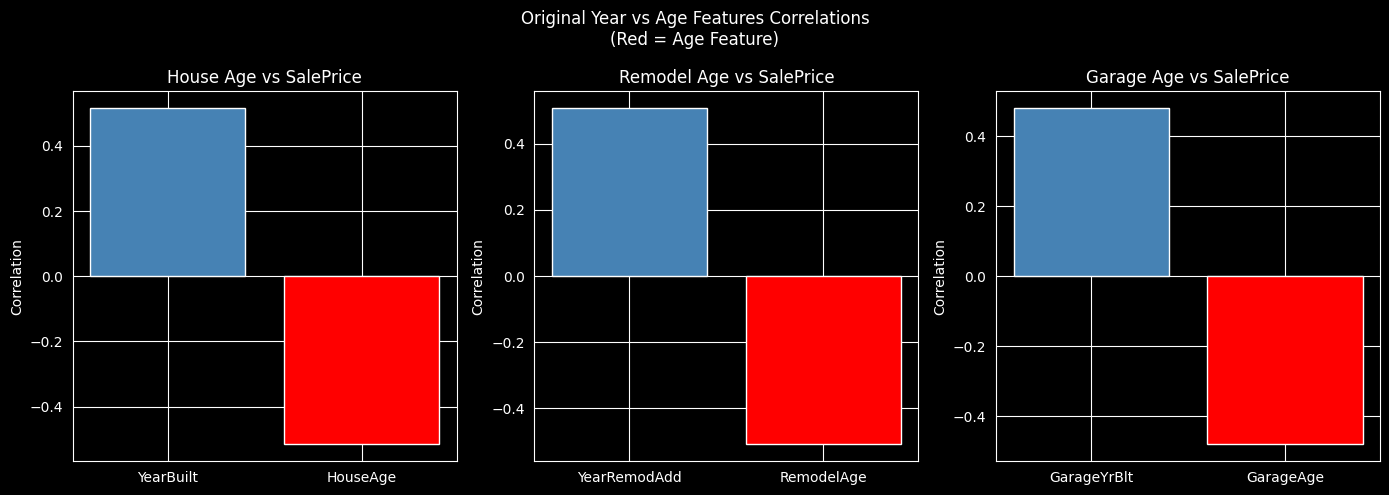

In [83]:
# Compare age features vs original year features
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# HouseAge vs YearBuilt
age_corrs_house = {
    'YearBuilt': train_df['YearBuilt'].corr(train_df['SalePrice']),
    'HouseAge': (train_df['YrSold'] - train_df['YearBuilt']).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[0].bar(age_corrs_house.keys(), age_corrs_house.values(), color=colors)
axes[0].set_title('House Age vs SalePrice')
axes[0].set_ylabel('Correlation')

# RemodelAge vs YearRemodAdd
age_corrs_remod = {
    'YearRemodAdd': train_df['YearRemodAdd'].corr(train_df['SalePrice']),
    'RemodelAge': (train_df['YrSold'] - train_df['YearRemodAdd']).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[1].bar(age_corrs_remod.keys(), age_corrs_remod.values(), color=colors)
axes[1].set_title('Remodel Age vs SalePrice')
axes[1].set_ylabel('Correlation')

# GarageAge vs GarageYrBlt
age_corrs_garage = {
    'GarageYrBlt': train_df['GarageYrBlt'].corr(train_df['SalePrice']),
    'GarageAge': (train_df['YrSold'] - train_df['GarageYrBlt']).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[2].bar(age_corrs_garage.keys(), age_corrs_garage.values(), color=colors)
axes[2].set_title('Garage Age vs SalePrice')
axes[2].set_ylabel('Correlation')

plt.suptitle('Original Year vs Age Features Correlations\n(Red = Age Feature)')
plt.tight_layout()
plt.savefig('images/age_feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

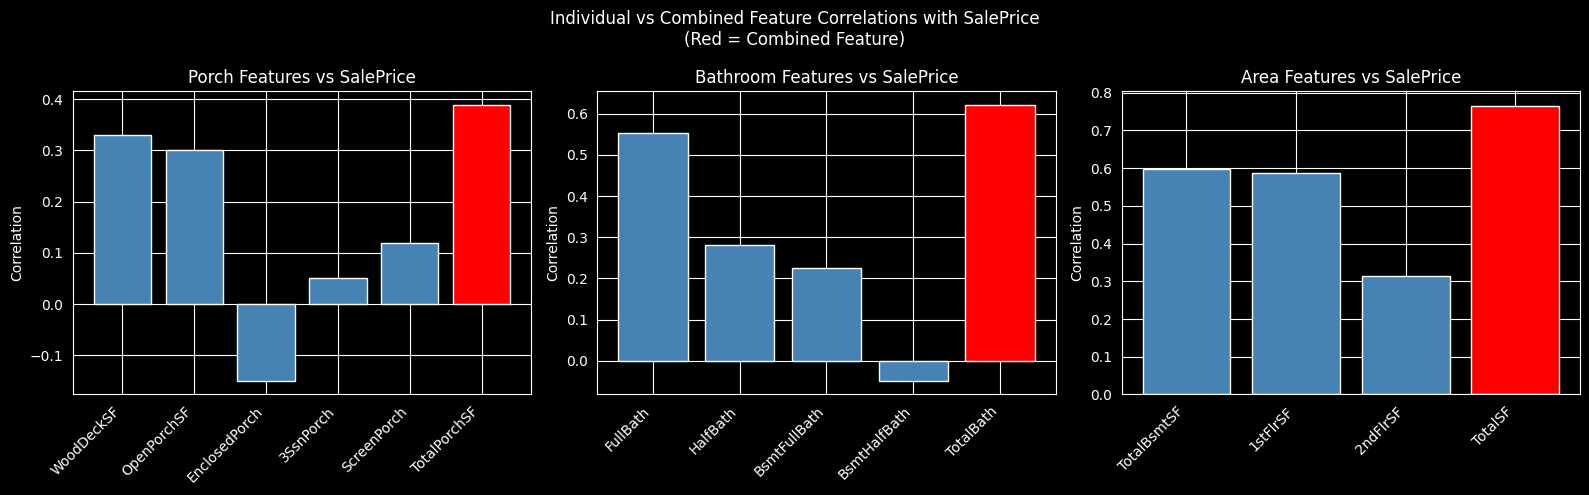

In [84]:
# Compare correlations — individual vs combined features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Porch features
porch_cols = ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
total_porch = (train_df['WoodDeckSF'] + train_df['OpenPorchSF'] +
               train_df['EnclosedPorch'] + train_df['3SsnPorch'] +
               train_df['ScreenPorch'])

porch_corrs = {col: train_df[col].corr(train_df['SalePrice']) for col in porch_cols}
porch_corrs['TotalPorchSF'] = total_porch.corr(train_df['SalePrice'])

colors = ['steelblue'] * len(porch_cols) + ['red']
axes[0].bar(porch_corrs.keys(), porch_corrs.values(), color=colors)
axes[0].set_title('Porch Features vs SalePrice')
axes[0].set_xticklabels(porch_corrs.keys(), rotation=45, ha='right')
axes[0].set_ylabel('Correlation')

# Bathroom count features
bath_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
total_bath = (train_df['FullBath'] + 0.5*train_df['HalfBath'] +
              train_df['BsmtFullBath'] + 0.5*train_df['BsmtHalfBath'])

bath_corrs = {col: train_df[col].corr(train_df['SalePrice']) for col in bath_cols}
bath_corrs['TotalBath'] = total_bath.corr(train_df['SalePrice'])

colors = ['steelblue'] * len(bath_cols) + ['red']
axes[1].bar(bath_corrs.keys(), bath_corrs.values(), color=colors)
axes[1].set_title('Bathroom Features vs SalePrice')
axes[1].set_xticklabels(bath_corrs.keys(), rotation=45, ha='right')
axes[1].set_ylabel('Correlation')

# Area features
area_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
total_sf = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']

area_corrs = {col: train_df[col].corr(train_df['SalePrice']) for col in area_cols}
area_corrs['TotalSF'] = total_sf.corr(train_df['SalePrice'])

colors = ['steelblue'] * len(area_cols) + ['red']
axes[2].bar(area_corrs.keys(), area_corrs.values(), color=colors)
axes[2].set_title('Area Features vs SalePrice')
axes[2].set_xticklabels(area_corrs.keys(), rotation=45, ha='right')
axes[2].set_ylabel('Correlation')

plt.suptitle('Individual vs Combined Feature Correlations with SalePrice\n(Red = Combined Feature)')
plt.tight_layout()
plt.savefig('images/area_count_feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

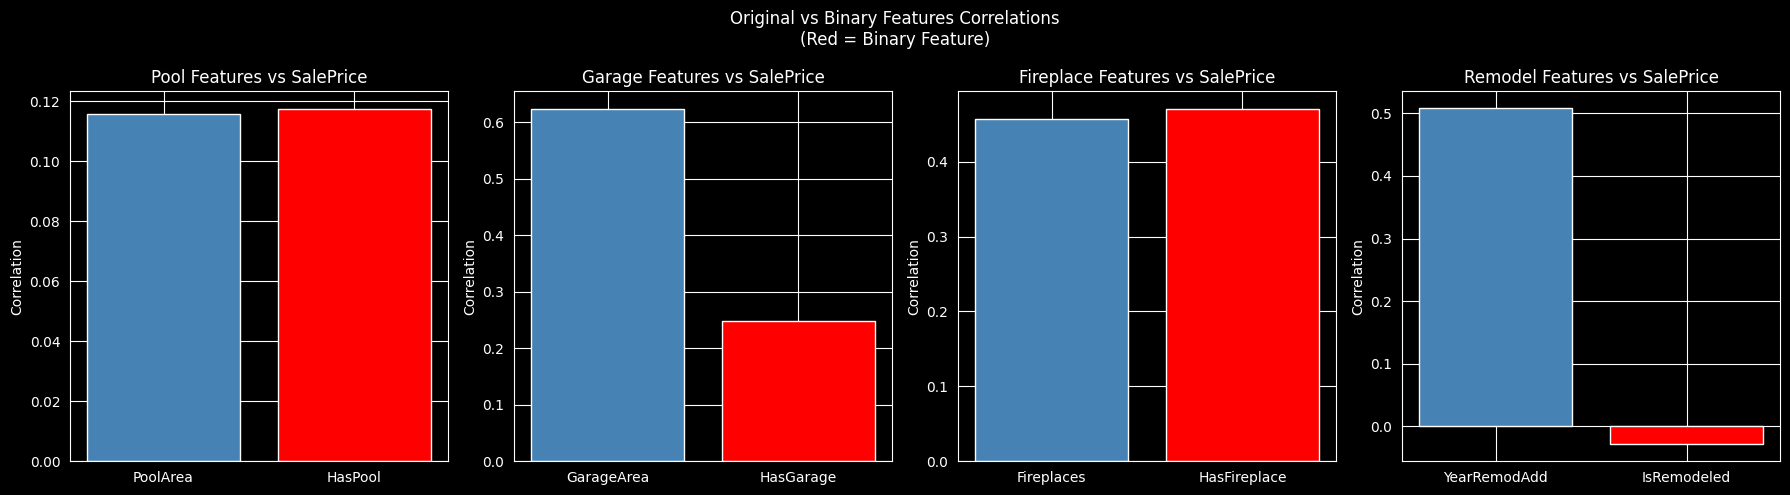

In [85]:
# Compare binary features vs original numeric features
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# HasPool vs PoolArea
pool_corrs = {
    'PoolArea': train_df['PoolArea'].corr(train_df['SalePrice']),
    'HasPool': (train_df['PoolArea'] > 0).astype(int).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[0].bar(pool_corrs.keys(), pool_corrs.values(), color=colors)
axes[0].set_title('Pool Features vs SalePrice')
axes[0].set_ylabel('Correlation')

# HasGarage vs GarageArea
garage_corrs = {
    'GarageArea': train_df['GarageArea'].corr(train_df['SalePrice']),
    'HasGarage': (train_df['GarageArea'] > 0).astype(int).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[1].bar(garage_corrs.keys(), garage_corrs.values(), color=colors)
axes[1].set_title('Garage Features vs SalePrice')
axes[1].set_ylabel('Correlation')

# HasFireplace vs Fireplaces
fire_corrs = {
    'Fireplaces': train_df['Fireplaces'].corr(train_df['SalePrice']),
    'HasFireplace': (train_df['Fireplaces'] > 0).astype(int).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[2].bar(fire_corrs.keys(), fire_corrs.values(), color=colors)
axes[2].set_title('Fireplace Features vs SalePrice')
axes[2].set_ylabel('Correlation')

# IsRemodeled vs YearRemodAdd
remod_corrs = {
    'YearRemodAdd': train_df['YearRemodAdd'].corr(train_df['SalePrice']),
    'IsRemodeled': (train_df['YearBuilt'] != train_df['YearRemodAdd']).astype(int).corr(train_df['SalePrice'])
}
colors = ['steelblue', 'red']
axes[3].bar(remod_corrs.keys(), remod_corrs.values(), color=colors)
axes[3].set_title('Remodel Features vs SalePrice')
axes[3].set_ylabel('Correlation')

plt.suptitle('Original vs Binary Features Correlations\n(Red = Binary Feature)')
plt.tight_layout()
plt.savefig('images/binary_feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

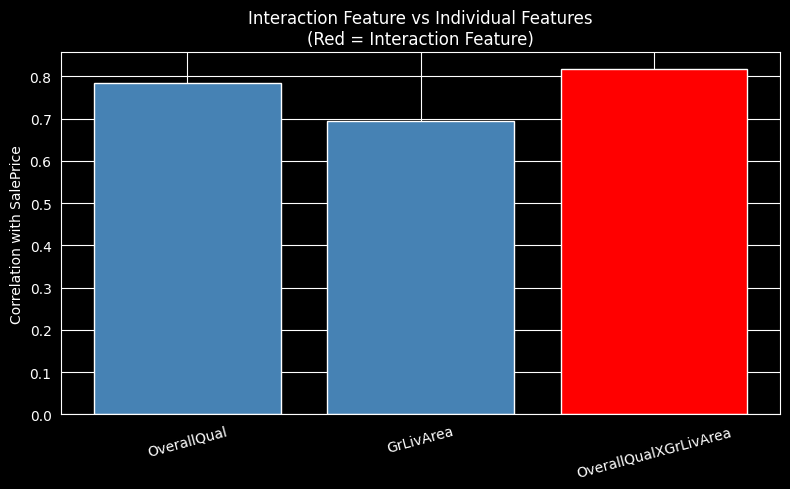

OverallQual: 0.79
GrLivArea: 0.70
OverallQualXGrLivArea: 0.82


In [86]:
# Compare interaction feature vs individual features
interaction_corrs = {
    'OverallQual': train_df['OverallQual'].corr(train_df['SalePrice']),
    'GrLivArea': train_df['GrLivArea'].corr(train_df['SalePrice']),
    'OverallQualXGrLivArea': (train_df['OverallQual'] * train_df['GrLivArea']).corr(train_df['SalePrice'])
}

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'steelblue', 'red']
plt.bar(interaction_corrs.keys(), interaction_corrs.values(), color=colors)
plt.title('Interaction Feature vs Individual Features\n(Red = Interaction Feature)')
plt.ylabel('Correlation with SalePrice')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('images/interaction_feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

for name, val in interaction_corrs.items():
    print(f"{name}: {val:.2f}")

In [87]:
def add_features(df):
    df = df.copy()

    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']

    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalPorchSF'] = (df['WoodDeckSF'] + df['OpenPorchSF'] +
                          df['EnclosedPorch'] + df['3SsnPorch'] +
                          df['ScreenPorch'])

    df['TotalBath'] = (df['FullBath'] + 0.5*df['HalfBath'] +
                       df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])

    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

    df['OverallQualXGrLivArea'] = df['OverallQual'] * df['GrLivArea']

    return df

In [88]:
# Apply feature engineering on train and test
X_fe = add_features(X.drop(index=outlier_idx))
X_test_fe = add_features(X_test_final)
y_fe = y.drop(index=outlier_idx)

print(f"Shape before FE: {X.drop(index=outlier_idx).shape}")
print(f"Shape after FE:  {X_fe.shape}")
print(f"\nNew features: {[c for c in X_fe.columns if c not in X.columns]}")

Shape before FE: (1166, 80)
Shape after FE:  (1166, 91)

New features: ['HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'HasPool', 'HasGarage', 'HasFireplace', 'IsRemodeled', 'OverallQualXGrLivArea']


In [90]:
# Verify new features correlation with SalePrice
new_features = [c for c in X_fe.columns if c not in X.columns]
y_temp = train_df.loc[X_fe.index, 'SalePrice']

new_corr = X_fe[new_features].corrwith(y_temp).sort_values(ascending=False)
print("New features correlation with SalePrice:")
print(new_corr.round(2))

New features correlation with SalePrice:
OverallQualXGrLivArea    0.87
TotalSF                  0.83
TotalBath                0.63
HasFireplace             0.47
TotalPorchSF             0.39
HasGarage                0.25
HasPool                  0.13
IsRemodeled             -0.03
GarageAge               -0.48
RemodelAge              -0.51
HouseAge                -0.52
dtype: float64


## Feature Selection

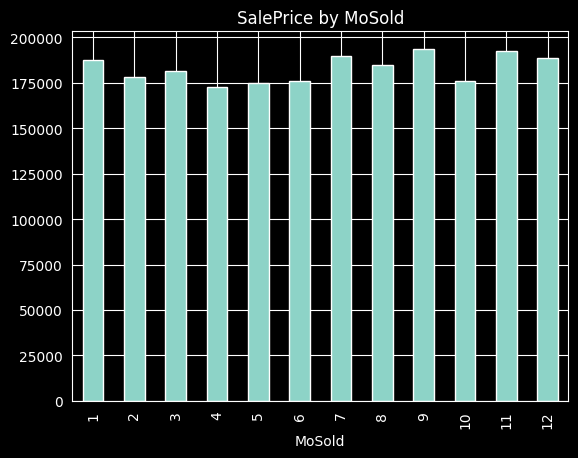

In [151]:
train_df.groupby('MoSold')['SalePrice'].mean().plot(kind='bar')
plt.title('SalePrice by MoSold')
plt.savefig('images/mosold.png', bbox_inches='tight', dpi=150)
plt.show()

In [152]:
explicit_drops = [
    'Id',
    'MoSold',
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF2',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
]

X_fs = X_fe.drop(columns=[c for c in explicit_drops if c in X_fe.columns])

print(f"Shape before explicit drops: {X_fe.shape}")
print(f"Shape after explicit drops:  {X_fs.shape}")
print(f"Dropped {X_fe.shape[1] - X_fs.shape[1]} columns")

Shape before explicit drops: (1166, 91)
Shape after explicit drops:  (1166, 76)
Dropped 15 columns


In [153]:
# Find highly correlated pairs in X_fs (after explicit drops)
num_cols_fs = X_fs.select_dtypes(include='number').columns.tolist()
corr_matrix = X_fs[num_cols_fs].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        if upper_triangle.loc[row, col] > 0.8:
            high_corr_pairs.append({
                'feature_1': row,
                'feature_2': col,
                'correlation': upper_triangle.loc[row, col].round(3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print("Highly correlated pairs (> 0.8):")
print(high_corr_df.to_string(index=False))

Highly correlated pairs (> 0.8):
   feature_1             feature_2  correlation
   YearBuilt              HouseAge        0.999
 GarageYrBlt             GarageAge        0.999
YearRemodAdd            RemodelAge        0.998
    PoolArea               HasPool        0.990
   GrLivArea OverallQualXGrLivArea        0.921
  Fireplaces          HasFireplace        0.902
  GarageCars            GarageArea        0.889
     TotalSF OverallQualXGrLivArea        0.870
   GrLivArea               TotalSF        0.862
   GrLivArea          TotRmsAbvGrd        0.826
   YearBuilt           GarageYrBlt        0.819
    HouseAge             GarageAge        0.819
 GarageYrBlt              HouseAge        0.818
   YearBuilt             GarageAge        0.818
 OverallQual OverallQualXGrLivArea        0.818


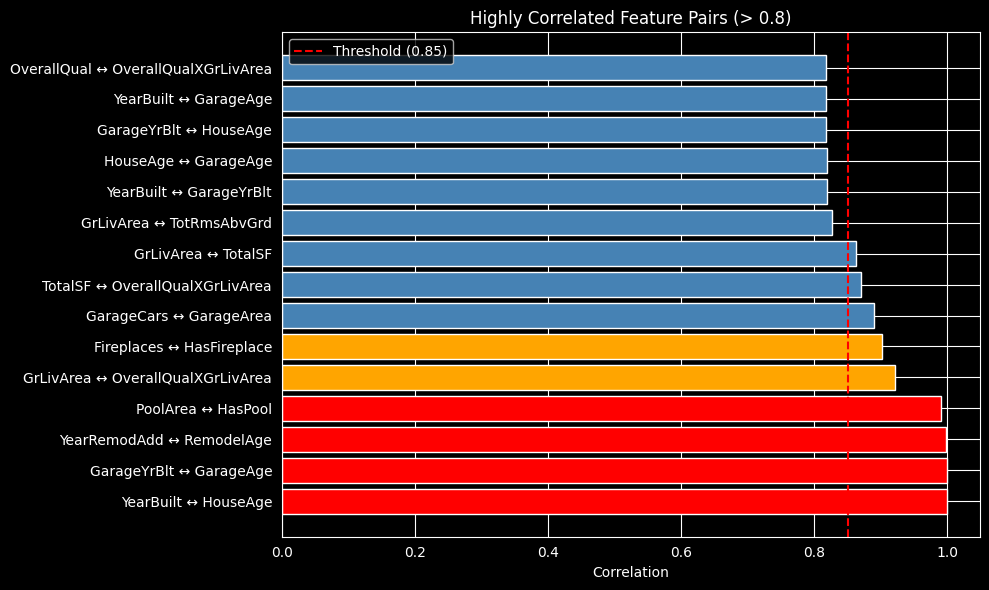

In [154]:
# Visualize highly correlated pairs
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0.95 else 'orange' if x > 0.90 else 'steelblue'
          for x in high_corr_df['correlation']]

plt.barh(
    [f"{row['feature_1']} ↔ {row['feature_2']}" for _, row in high_corr_df.iterrows()],
    high_corr_df['correlation'],
    color=colors
)
plt.axvline(x=0.85, color='red', linestyle='--', label='Threshold (0.85)')
plt.xlabel('Correlation')
plt.title('Highly Correlated Feature Pairs (> 0.8)')
plt.legend()
plt.tight_layout()
plt.savefig('images/highly_correlated_pairs.png', bbox_inches='tight', dpi=150)
plt.show()

In [155]:
# Drop one from each highly correlated pair
cols_to_drop_corr = ['GarageYrBlt', 'YearBuilt', 'YearRemodAdd', 'PoolArea', 'Fireplaces', 'GarageArea']

X_fs = X_fs.drop(columns=[c for c in cols_to_drop_corr if c in X_fs.columns])
print(f"Shape after correlation filter: {X_fs.shape}")

Shape after correlation filter: (1166, 70)


In [156]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Build preprocessor for current X_fs
num_cols_fs = X_fs.select_dtypes(include='number').columns.tolist()
cat_cols_fs = X_fs.select_dtypes(include='object').columns.tolist()
ordinal_cols_fs = [col for col in all_ordinal_cols if col in X_fs.columns]
remaining_cat_fs = [col for col in cat_cols_fs if col not in ordinal_cols_fs]

preprocessor_fs = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols_fs),
    ('ordinal', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='TA')),
        ('encoder', OrdinalEncoder(
            categories=[all_ordinal_categories[all_ordinal_cols.index(col)] for col in ordinal_cols_fs],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ]), ordinal_cols_fs),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), remaining_cat_fs)
])

# Preprocess and scale for Lasso
X_fs_processed = preprocessor_fs.fit_transform(X_fs)
scaler = StandardScaler()
X_fs_scaled = scaler.fit_transform(X_fs_processed)

print(f"Processed shape: {X_fs_processed.shape}")

Processed shape: (1166, 223)


In [157]:
# Find best alpha with cross validation
lasso_cv = LassoCV(
    alphas=[0.0001, 0.001, 0.01, 0.1, 1.0],
    cv=5,
    random_state=42,
    max_iter=10000
)
lasso_cv.fit(X_fs_scaled, y_fe)

feature_names = preprocessor_fs.get_feature_names_out()
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

non_zero = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False)
zero = lasso_coefs[lasso_coefs == 0]

print(f"Best alpha: {lasso_cv.alpha_:.4f}")
print(f"Non-zero features: {len(non_zero)}")
print(f"Zero features (dropped by Lasso): {len(zero)}")
print(f"\nTop 20:")
print(non_zero.head(20).round(4))

Best alpha: 0.0010
Non-zero features: 151
Zero features (dropped by Lasso): 72

Top 20:
num__TotalSF                  0.0804
num__GrLivArea                0.0776
num__OverallQual              0.0610
num__HouseAge                 0.0548
num__OverallCond              0.0399
num__BsmtFinSF1               0.0281
num__GarageCars               0.0276
ordinal__Functional           0.0253
cat__Neighborhood_Crawfor     0.0200
num__TotalBath                0.0190
cat__Exterior1st_BrkFace      0.0179
cat__MSZoning_C (all)         0.0176
cat__BldgType_1Fam            0.0175
num__RemodelAge               0.0169
num__TotalPorchSF             0.0164
cat__CentralAir_N             0.0155
num__HasFireplace             0.0155
cat__MSZoning_RM              0.0154
cat__Neighborhood_StoneBr     0.0151
cat__SaleCondition_Abnorml    0.0145
dtype: float64


In [158]:
# LightGBM Feature Importance
import lightgbm as lgb

pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor_fs),
    ('model', lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ))
])
pipeline_lgb.fit(X_fs, y_fe)

feature_names = preprocessor_fs.get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': pipeline_lgb.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print(f"Zero importance features: {(importance_df['importance'] == 0).sum()}")
print(f"\nTop 20:")
print(importance_df.head(20).to_string(index=False))

Zero importance features: 102

Top 20:
                   feature  importance
              num__TotalSF        1185
num__OverallQualXGrLivArea        1172
              num__LotArea        1034
         num__TotalPorchSF         970
            num__BsmtUnfSF         923
            num__GrLivArea         838
             num__HouseAge         665
           num__BsmtFinSF1         639
          num__LotFrontage         639
           num__RemodelAge         570
           num__MasVnrArea         552
            num__GarageAge         448
               num__YrSold         327
          num__OverallCond         326
            num__TotalBath         246
           num__GarageCars         211
          num__OverallQual         200
 cat__SaleCondition_Normal         161
           num__MSSubClass         161
         num__TotRmsAbvGrd         158


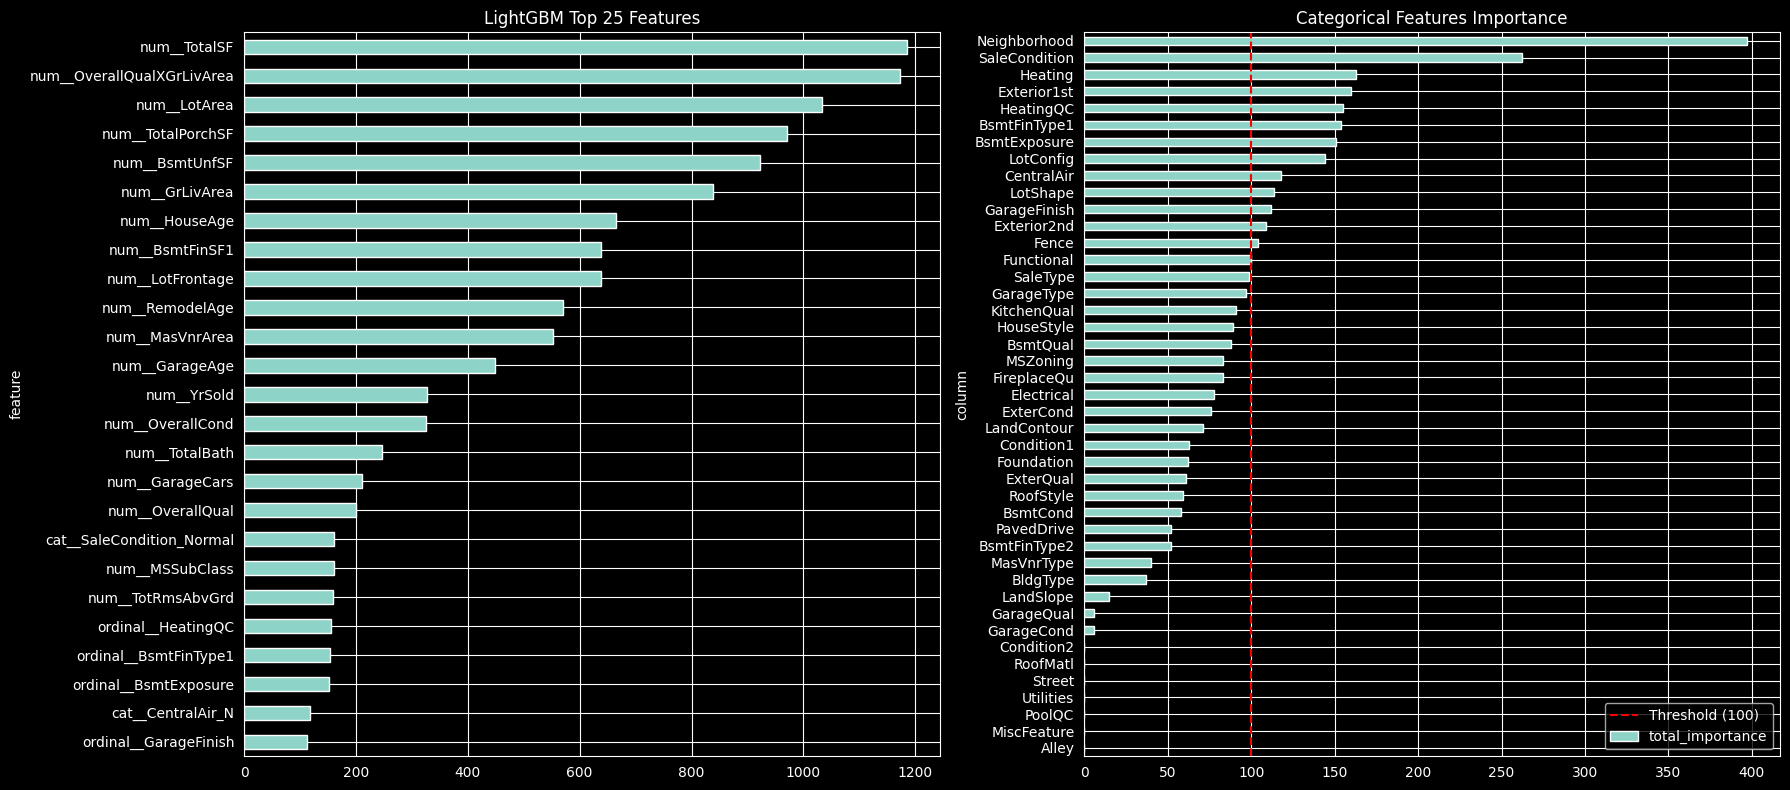

In [159]:
# Categorical importance
cat_importance = {}
for col in X_fs.select_dtypes(include='object').columns:
    col_features = importance_df[
        importance_df['feature'].str.contains(f'cat__{col}_') |
        importance_df['feature'].str.contains(f'ordinal__{col}')
    ]
    cat_importance[col] = col_features['importance'].sum()

cat_imp_df = pd.DataFrame({
    'column': list(cat_importance.keys()),
    'total_importance': list(cat_importance.values())
}).sort_values('total_importance', ascending=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 25 overall features
importance_df.head(25).plot(x='feature', y='importance',
                             kind='barh', ax=axes[0], legend=False)
axes[0].set_title('LightGBM Top 25 Features')
axes[0].invert_yaxis()

# Categorical importance
cat_imp_df.plot(x='column', y='total_importance',
                kind='barh', ax=axes[1], legend=False)
axes[1].axvline(x=100, color='red', linestyle='--', label='Threshold (100)')
axes[1].set_title('Categorical Features Importance')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('images/lgb_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [160]:
# Drop low importance categorical columns

# Categorical columns below threshold
low_imp_cat = cat_imp_df[cat_imp_df['total_importance'] < 100]['column'].tolist()
print(f"Categorical columns to drop (importance < 100): {len(low_imp_cat)}")
print(low_imp_cat)

# Apply drops
X_fs_final = X_fs.drop(columns=[c for c in low_imp_cat if c in X_fs.columns])
print(f"\nShape before cat drops: {X_fs.shape}")
print(f"Shape after cat drops:  {X_fs_final.shape}")
print(f"\nRemaining categorical: {X_fs_final.select_dtypes(include='object').columns.tolist()}")
print(f"Remaining numeric: {X_fs_final.select_dtypes(include='number').columns.tolist()}")

Categorical columns to drop (importance < 100): 29
['SaleType', 'GarageType', 'KitchenQual', 'HouseStyle', 'BsmtQual', 'MSZoning', 'FireplaceQu', 'Electrical', 'ExterCond', 'LandContour', 'Condition1', 'Foundation', 'ExterQual', 'RoofStyle', 'BsmtCond', 'PavedDrive', 'BsmtFinType2', 'MasVnrType', 'BldgType', 'LandSlope', 'GarageQual', 'GarageCond', 'Condition2', 'RoofMatl', 'Street', 'Utilities', 'PoolQC', 'MiscFeature', 'Alley']

Shape before cat drops: (1166, 70)
Shape after cat drops:  (1166, 41)

Remaining categorical: ['LotShape', 'LotConfig', 'Neighborhood', 'Exterior1st', 'Exterior2nd', 'BsmtExposure', 'BsmtFinType1', 'Heating', 'HeatingQC', 'CentralAir', 'Functional', 'GarageFinish', 'Fence', 'SaleCondition']
Remaining numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'MiscVal', 'YrSold', 'HouseAge', 'RemodelAge', 'Gar

In [161]:
# Compare feature sets
def build_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    ord_cols = [col for col in all_ordinal_cols if col in X.columns]
    rem_cat = [col for col in cat_cols if col not in ord_cols]
    ord_indices = [all_ordinal_cols.index(col) for col in ord_cols]
    ord_cats = [all_ordinal_categories[i] for i in ord_indices]

    fresh_ordinal = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='TA')),
        ('encoder', OrdinalEncoder(
            categories=ord_cats,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])

    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('ordinal', fresh_ordinal, ord_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), rem_cat)
    ])

In [162]:
# Test X_fs (before cat drops) vs X_fs_final (after cat drops)
from sklearn.linear_model import Ridge

feature_sets = {
    'FS_before_cat_drops': X_fs,
    'FS_final': X_fs_final
}

results_ridge = {}
results_lgb = {}

for name, X_i in feature_sets.items():
    prep = build_preprocessor(X_i)

    # Ridge
    pipeline_r = Pipeline([('preprocessor', prep), ('model', Ridge(alpha=10))])
    scores_r = cross_val_score(pipeline_r, X_i, y_fe, cv=kf,
                                scoring='neg_root_mean_squared_error')
    results_ridge[name] = (-scores_r.mean(), scores_r.std())

    # LightGBM
    pipeline_l = Pipeline([('preprocessor', prep),
                            ('model', lgb.LGBMRegressor(n_estimators=500,
                                                         learning_rate=0.05,
                                                         random_state=42,
                                                         verbose=-1))])
    scores_l = cross_val_score(pipeline_l, X_i, y_fe, cv=kf,
                                scoring='neg_root_mean_squared_error')
    results_lgb[name] = (-scores_l.mean(), scores_l.std())

print(f"{'Feature Set':<25} {'Ridge RMSE':<15} {'LGB RMSE':<15} {'Features'}")
print("-"*60)
for name, X_i in feature_sets.items():
    print(f"{name:<25} {results_ridge[name][0]:.4f}          "
          f"{results_lgb[name][0]:.4f}          "
          f"{X_i.shape[1]}")

Feature Set               Ridge RMSE      LGB RMSE        Features
------------------------------------------------------------
FS_before_cat_drops       0.1107          0.1217          70
FS_final                  0.1110          0.1216          41


In [163]:
# Check numeric importance
num_importance = importance_df[importance_df['feature'].str.startswith('num__')]
num_importance = num_importance.copy()
num_importance['original'] = num_importance['feature'].str.replace('num__', '')
print("Numeric features importance:")
print(num_importance[['original', 'importance']].sort_values('importance').head(20).to_string(index=False))

Numeric features importance:
    original  importance
LowQualFinSF           0
   HasGarage           0
     HasPool           0
     MiscVal          13
KitchenAbvGr          36
BedroomAbvGr          65
HasFireplace          84
 IsRemodeled          84
TotRmsAbvGrd         158
  MSSubClass         161
 OverallQual         200
  GarageCars         211
   TotalBath         246
 OverallCond         326
      YrSold         327
   GarageAge         448
  MasVnrArea         552
  RemodelAge         570
 LotFrontage         639
  BsmtFinSF1         639


In [146]:
experiments = {
    'fs_before_cat_drops': (X_fs, results_ridge['FS_before_cat_drops'], results_lgb['FS_before_cat_drops']),
    'fs_after_cat_drops': (X_fs_final, results_ridge['FS_final'], results_lgb['FS_final'])
}

for name, (X_i, ridge_res, lgb_res) in experiments.items():
    with mlflow.start_run(run_name=f"fs_{name}_ridge"):
        mlflow.log_param("feature_set", name)
        mlflow.log_param("n_features", X_i.shape[1])
        mlflow.log_param("model", "Ridge")
        mlflow.log_param("alpha", 10)
        mlflow.log_metric("cv_rmse", ridge_res[0])
        mlflow.log_metric("cv_std", ridge_res[1])

    with mlflow.start_run(run_name=f"fs_{name}_lgb"):
        mlflow.log_param("feature_set", name)
        mlflow.log_param("n_features", X_i.shape[1])
        mlflow.log_param("model", "LightGBM")
        mlflow.log_param("n_estimators", 500)
        mlflow.log_param("learning_rate", 0.05)
        mlflow.log_metric("cv_rmse", lgb_res[0])
        mlflow.log_metric("cv_std", lgb_res[1])

In [164]:
# Drop low importance numeric columns
low_imp_num = ['LowQualFinSF', 'HasGarage', 'HasPool', 'MiscVal', 'KitchenAbvGr']

X_fs_final2 = X_fs_final.drop(columns=[c for c in low_imp_num if c in X_fs_final.columns])
print(f"Shape after numeric drops: {X_fs_final2.shape}")
print(f"\nFinal numeric: {X_fs_final2.select_dtypes(include='number').columns.tolist()}")
print(f"Final categorical: {X_fs_final2.select_dtypes(include='object').columns.tolist()}")

Shape after numeric drops: (1166, 36)

Final numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'YrSold', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'HasFireplace', 'IsRemodeled', 'OverallQualXGrLivArea']
Final categorical: ['LotShape', 'LotConfig', 'Neighborhood', 'Exterior1st', 'Exterior2nd', 'BsmtExposure', 'BsmtFinType1', 'Heating', 'HeatingQC', 'CentralAir', 'Functional', 'GarageFinish', 'Fence', 'SaleCondition']


In [165]:
# Test final feature set
prep_final2 = build_preprocessor(X_fs_final2)

pipeline_r = Pipeline([('preprocessor', prep_final2), ('model', Ridge(alpha=10))])
scores_r = cross_val_score(pipeline_r, X_fs_final2, y_fe, cv=kf,
                            scoring='neg_root_mean_squared_error')
rmse_ridge_final = -scores_r.mean()

pipeline_l = Pipeline([('preprocessor', prep_final2),
                        ('model', lgb.LGBMRegressor(n_estimators=500,
                                                     learning_rate=0.05,
                                                     random_state=42,
                                                     verbose=-1))])
scores_l = cross_val_score(pipeline_l, X_fs_final2, y_fe, cv=kf,
                            scoring='neg_root_mean_squared_error')
rmse_lgb_final = -scores_l.mean()

print(f"FS_final2 Ridge: {rmse_ridge_final:.4f} ± {scores_r.std():.4f} | features={X_fs_final2.shape[1]}")
print(f"FS_final2 LGB:   {rmse_lgb_final:.4f} ± {scores_l.std():.4f} | features={X_fs_final2.shape[1]}")

FS_final2 Ridge: 0.1111 ± 0.0073 | features=36
FS_final2 LGB:   0.1223 ± 0.0043 | features=36


In [149]:
with mlflow.start_run(run_name="fs_final2_numeric_drops_ridge"):
    mlflow.log_param("feature_set", "FS_final2")
    mlflow.log_param("n_features", X_fs_final2.shape[1])
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 10)
    mlflow.log_metric("cv_rmse", rmse_ridge_final)
    mlflow.log_metric("cv_std", scores_r.std())

with mlflow.start_run(run_name="fs_final2_numeric_drops_lgb"):
    mlflow.log_param("feature_set", "FS_final2")
    mlflow.log_param("n_features", X_fs_final2.shape[1])
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("cv_rmse", rmse_lgb_final)
    mlflow.log_metric("cv_std", scores_l.std())

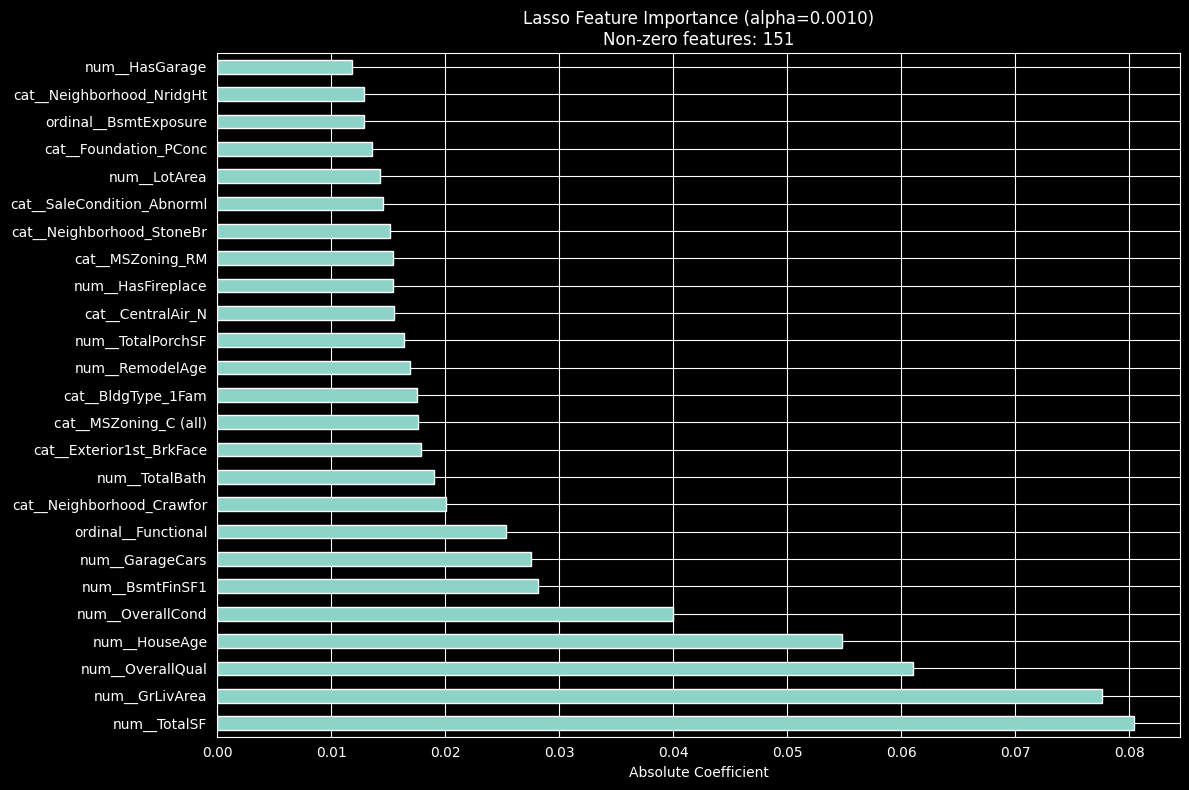

In [166]:
# Visualize Lasso coefficients
plt.figure(figsize=(12, 8))
non_zero.head(25).plot(kind='barh')
plt.title(f'Lasso Feature Importance (alpha={lasso_cv.alpha_:.4f})\nNon-zero features: {len(non_zero)}')
plt.xlabel('Absolute Coefficient')
plt.tight_layout()
plt.savefig('images/lasso_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [167]:
# LightGBM Feature Importance
import lightgbm as lgb

# Build pipeline with LightGBM
pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor_fs),
    ('model', lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ))
])

# Train on full training set
pipeline_lgb.fit(X_fs, y_fe)

# Get feature importance
feature_names = preprocessor_fs.get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': pipeline_lgb.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 features by LightGBM importance:")
print(importance_df.head(25).to_string(index=False))
print(f"\nFeatures with 0 importance: {(importance_df['importance'] == 0).sum()}")

Top 25 features by LightGBM importance:
                   feature  importance
              num__TotalSF        1185
num__OverallQualXGrLivArea        1172
              num__LotArea        1034
         num__TotalPorchSF         970
            num__BsmtUnfSF         923
            num__GrLivArea         838
             num__HouseAge         665
           num__BsmtFinSF1         639
          num__LotFrontage         639
           num__RemodelAge         570
           num__MasVnrArea         552
            num__GarageAge         448
               num__YrSold         327
          num__OverallCond         326
            num__TotalBath         246
           num__GarageCars         211
          num__OverallQual         200
 cat__SaleCondition_Normal         161
           num__MSSubClass         161
         num__TotRmsAbvGrd         158
        ordinal__HeatingQC         155
     ordinal__BsmtFinType1         154
     ordinal__BsmtExposure         151
         cat__CentralAir

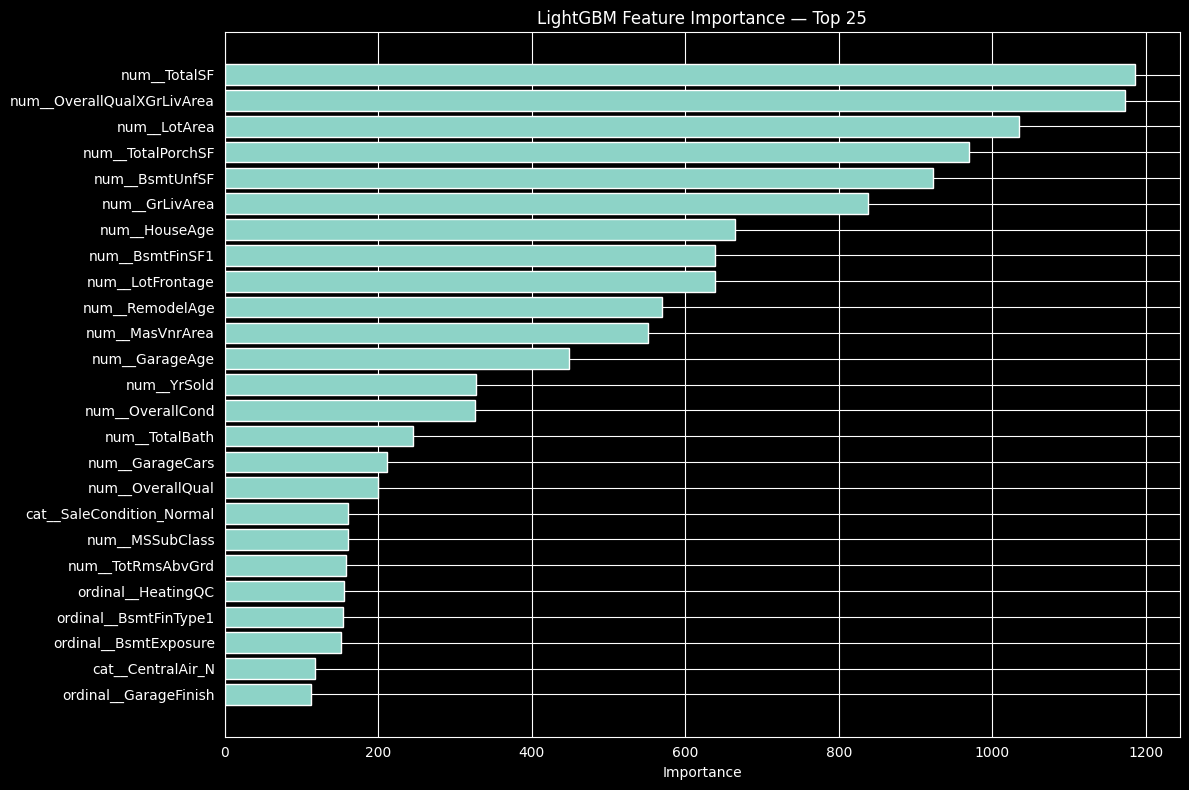

In [172]:
# Visualize top 25 features
plt.figure(figsize=(12, 8))
top25 = importance_df.head(25)
plt.barh(top25['feature'][::-1], top25['importance'][::-1])
plt.title('LightGBM Feature Importance — Top 25')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('images/lgb_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [169]:
# Compare Lasso vs LightGBM — which features both agree on
lasso_kept = set(lasso_coefs[lasso_coefs != 0].index)
lgb_top50 = set(importance_df.head(50)['feature'].values)

both_agree = lasso_kept.intersection(lgb_top50)
only_lasso = lasso_kept - lgb_top50
only_lgb = lgb_top50 - lasso_kept

print(f"Both methods agree on: {len(both_agree)} features")
print(f"Only Lasso kept: {len(only_lasso)} features")
print(f"Only LightGBM top50: {len(only_lgb)} features")

Both methods agree on: 37 features
Only Lasso kept: 114 features
Only LightGBM top50: 13 features


In [171]:
# Features with 0 importance in LightGBM
zero_importance = importance_df[importance_df['importance'] == 0]['feature'].tolist()

# Get original column names (remove prefix)
def get_original_cols(feature_list, prefix):
    return [f.replace(prefix, '') for f in feature_list if f.startswith(prefix)]

zero_num = get_original_cols(zero_importance, 'num__')
print("Zero importance numeric cols:")
print(zero_num)

Zero importance numeric cols:
['HasGarage', 'HasPool', 'LowQualFinSF']


## Training

In [173]:
# ── 6. Model Training ──
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb
import lightgbm as lgb

# Final preprocessor for training
preprocessor_train = build_preprocessor(X_train_final)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [176]:
results_summary = []

def train_and_log(model, model_name, params, run_name):
    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X_train_final)),
        ('model', model)
    ])

    cv_scores = cross_val_score(pipeline, X_train_final, y_train_final,
                                 cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()

    pipeline.fit(X_train_final, y_train_final)
    train_preds = pipeline.predict(X_train_final)
    train_rmse = root_mean_squared_error(y_train_final, train_preds)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model", model_name)
        mlflow.log_param("feature_set", "FS_final2_36")
        mlflow.log_params(params)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("cv_rmse", cv_rmse)
        mlflow.log_metric("cv_std", cv_std)
        mlflow.log_metric("overfit_gap", train_rmse - cv_rmse)

    results_summary.append({
        'run_name': run_name,
        'model': model_name,
        'params': str(params),
        'train_rmse': round(train_rmse, 4),
        'cv_rmse': round(cv_rmse, 4),
        'cv_std': round(cv_std, 4),
        'gap': round(train_rmse - cv_rmse, 4)
    })

    return pipeline, cv_rmse, train_rmse

In [177]:
# Linear Regression
lr_pipeline, lr_cv, lr_train = train_and_log(
    LinearRegression(),
    "LinearRegression",
    {},
    "baseline_linear_regression"
)

In [178]:
# Decision Tree with multiple depths
dt_params = [
    {"max_depth": 2},
    {"max_depth": 3},
    {"max_depth": 5},
    {"max_depth": 10},
    {"max_depth": None}
]

for params in dt_params:
    depth_str = str(params['max_depth'])
    train_and_log(
        DecisionTreeRegressor(random_state=42, **params),
        "DecisionTree",
        params,
        f"baseline_dt_depth{depth_str}"
    )

In [179]:
# Ridge with multiple alphas
ridge_params = [
    {"alpha": 0.1},
    {"alpha": 1.0},
    {"alpha": 10},
    {"alpha": 100},
]

for params in ridge_params:
    train_and_log(
        Ridge(**params),
        "Ridge",
        params,
        f"baseline_ridge_alpha{params['alpha']}"
    )

In [180]:
# Summary after all baseline models
summary_df = pd.DataFrame(results_summary)
summary_df['status'] = summary_df['gap'].apply(
    lambda x: 'overfit!' if x < -0.02 else 'underfit!' if x > 0.02 else 'good'
)
print(summary_df[['run_name', 'train_rmse', 'cv_rmse', 'gap', 'status']].to_string(index=False))

                  run_name  train_rmse  cv_rmse     gap   status
baseline_linear_regression      0.1004   0.1127 -0.0123     good
        baseline_dt_depth2      0.2275   0.2341 -0.0066     good
        baseline_dt_depth3      0.1940   0.2087 -0.0147     good
        baseline_dt_depth5      0.1420   0.1802 -0.0382 overfit!
       baseline_dt_depth10      0.0515   0.1913 -0.1398 overfit!
     baseline_dt_depthNone      0.0000   0.1902 -0.1902 overfit!
   baseline_ridge_alpha0.1      0.1004   0.1124 -0.0121     good
   baseline_ridge_alpha1.0      0.1005   0.1115 -0.0110     good
    baseline_ridge_alpha10      0.1025   0.1114 -0.0090     good
   baseline_ridge_alpha100      0.1102   0.1170 -0.0068     good


In [181]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Random Forest — multiple configs
rf_params = [
    {"n_estimators": 100, "max_depth": 5},    # shallow — underfit
    {"n_estimators": 100, "max_depth": 10},   # medium
    {"n_estimators": 100, "max_depth": None}, # full depth — might overfit
    {"n_estimators": 500, "max_depth": None}, # more trees
]

for params in rf_params:
    train_and_log(
        RandomForestRegressor(random_state=42, n_jobs=-1, **params),
        "RandomForest",
        params,
        f"advanced_rf_depth{params['max_depth']}_n{params['n_estimators']}"
    )

In [182]:
# XGBoost — multiple configs
xgb_params = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},   # baseline
    {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.05},  # more trees
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.05},  # deeper
    {"n_estimators": 1000, "max_depth": 3, "learning_rate": 0.01}, # slow learning
]

for params in xgb_params:
    train_and_log(
        xgb.XGBRegressor(random_state=42, verbosity=0, **params),
        "XGBoost",
        params,
        f"advanced_xgb_depth{params['max_depth']}_n{params['n_estimators']}_lr{params['learning_rate']}"
    )

In [183]:
# LightGBM — multiple configs
lgb_params = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.05},
    {"n_estimators": 1000, "max_depth": 3, "learning_rate": 0.01},
]

for params in lgb_params:
    train_and_log(
        lgb.LGBMRegressor(random_state=42, verbose=-1, **params),
        "LightGBM",
        params,
        f"advanced_lgb_depth{params['max_depth']}_n{params['n_estimators']}_lr{params['learning_rate']}"
    )

In [188]:
# Print advanced models summary
summary_df = pd.DataFrame(results_summary)
advanced = summary_df[summary_df['run_name'].str.startswith('advanced')]
print(advanced[['run_name', 'train_rmse', 'cv_rmse', 'gap']].to_string(index=False))

                        run_name  train_rmse  cv_rmse     gap
         advanced_rf_depth5_n100      0.1176   0.1485 -0.0308
        advanced_rf_depth10_n100      0.0586   0.1350 -0.0764
      advanced_rf_depthNone_n100      0.0512   0.1338 -0.0827
      advanced_rf_depthNone_n500      0.0493   0.1327 -0.0834
  advanced_xgb_depth3_n100_lr0.1      0.0783   0.1183 -0.0400
 advanced_xgb_depth3_n500_lr0.05      0.0571   0.1172 -0.0601
 advanced_xgb_depth6_n500_lr0.05      0.0085   0.1300 -0.1215
advanced_xgb_depth3_n1000_lr0.01      0.0781   0.1180 -0.0399
  advanced_lgb_depth3_n100_lr0.1      0.0854   0.1190 -0.0336
 advanced_lgb_depth3_n500_lr0.05      0.0665   0.1180 -0.0515
 advanced_lgb_depth6_n500_lr0.05      0.0333   0.1223 -0.0890
advanced_lgb_depth3_n1000_lr0.01      0.0838   0.1185 -0.0347


In [191]:
# Hyperparameter Optimization — LightGBM + Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X_train_final)),
        ('model', lgb.LGBMRegressor(random_state=42, verbose=-1, **params))
    ])

    scores = cross_val_score(pipeline, X_train_final, y_train_final,
                              cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

# Run optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best trial:")
print(f"  cv_rmse: {study.best_value:.4f}")
print(f"  params:  {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best trial:
  cv_rmse: 0.1128
  params:  {'n_estimators': 1774, 'max_depth': 3, 'learning_rate': 0.010066190748081008, 'num_leaves': 182, 'min_child_samples': 7, 'subsample': 0.5666411053162071, 'colsample_bytree': 0.5131747753911893, 'reg_alpha': 0.025895378283066435, 'reg_lambda': 0.27713663567281344}


In [192]:
# Train best model and log to MLflow
best_params = study.best_params

best_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(X_train_final)),
    ('model', lgb.LGBMRegressor(random_state=42, verbose=-1, **best_params))
])

# CV score
scores = cross_val_score(best_pipeline, X_train_final, y_train_final,
                          cv=kf, scoring='neg_root_mean_squared_error')
cv_rmse = -scores.mean()
cv_std = scores.std()

# Train RMSE
best_pipeline.fit(X_train_final, y_train_final)
train_preds = best_pipeline.predict(X_train_final)
train_rmse = root_mean_squared_error(y_train_final, train_preds)

print(f"Best LightGBM:")
print(f"  train_rmse: {train_rmse:.4f}")
print(f"  cv_rmse:    {cv_rmse:.4f} ± {cv_std:.4f}")
print(f"  gap:        {train_rmse - cv_rmse:.4f}")

Best LightGBM:
  train_rmse: 0.0681
  cv_rmse:    0.1128 ± 0.0050
  gap:        -0.0447


In [193]:
with mlflow.start_run(run_name="hpo_lgb_optuna_best_100"):
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("feature_set", "FS_final2_36")
    mlflow.log_param("hpo_method", "Optuna")
    mlflow.log_param("n_trials", 100)
    mlflow.log_params(best_params)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("cv_rmse", cv_rmse)
    mlflow.log_metric("cv_std", cv_std)
    mlflow.log_metric("overfit_gap", train_rmse - cv_rmse)

    mlflow.sklearn.log_model(
        best_pipeline,
        "model",
        registered_model_name="HousePrices_Best"
    )

Successfully registered model 'HousePrices_Best'.
2026/04/12 15:45:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_Best, version 1
Created version '1' of model 'HousePrices_Best'.


In [194]:
# HPO — Ridge + Optuna
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.01, 1000.0, log=True)

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X_train_final)),
        ('model', Ridge(alpha=alpha))
    ])

    scores = cross_val_score(pipeline, X_train_final, y_train_final,
                              cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(objective_ridge, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best Ridge:")
print(f"  cv_rmse: {study_ridge.best_value:.4f}")
print(f"  alpha:   {study_ridge.best_params['alpha']:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best Ridge:
  cv_rmse: 0.1111
  alpha:   3.6533


In [196]:
# Build best Ridge pipeline from HPO results
best_alpha = study_ridge.best_params['alpha']

best_ridge_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(X_train_final)),
    ('model', Ridge(alpha=best_alpha))
])

# CV score
scores = cross_val_score(best_ridge_pipeline, X_train_final, y_train_final,
                          cv=kf, scoring='neg_root_mean_squared_error')
cv_rmse_ridge = -scores.mean()

# Train
best_ridge_pipeline.fit(X_train_final, y_train_final)
train_rmse_ridge = root_mean_squared_error(y_train_final,
                                            best_ridge_pipeline.predict(X_train_final))

print(f"alpha:      {best_alpha:.4f}")
print(f"train_rmse: {train_rmse_ridge:.4f}")
print(f"cv_rmse:    {cv_rmse_ridge:.4f}")

alpha:      3.6533
train_rmse: 0.1012
cv_rmse:    0.1111


In [198]:
# Prepare test_df correctly
X_test_processed = test_df.drop(columns=['SalePrice']).copy()

# Step 1: add features
X_test_processed = add_features(X_test_processed)

# Step 2: keep only same columns as X_train_final
X_test_processed = X_test_processed[X_train_final.columns]

y_test = np.log1p(test_df['SalePrice'])

# Test RMSE
test_preds = best_ridge_pipeline.predict(X_test_processed)
test_rmse = root_mean_squared_error(y_test, test_preds)

print(f"train_rmse: {train_rmse_ridge:.4f}")
print(f"cv_rmse:    {cv_rmse_ridge:.4f}")
print(f"test_rmse:  {test_rmse:.4f}")

train_rmse: 0.1012
cv_rmse:    0.1111
test_rmse:  0.1304


In [199]:
with mlflow.start_run(run_name="final_model_ridge_hpo"):
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("hpo_method", "Optuna")
    mlflow.log_param("feature_set", "FS_final2_36")
    mlflow.log_param("alpha", best_alpha)
    mlflow.log_metric("train_rmse", train_rmse_ridge)
    mlflow.log_metric("cv_rmse", cv_rmse_ridge)
    mlflow.log_metric("cv_std", scores.std())
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("overfit_gap", train_rmse_ridge - cv_rmse_ridge)

    mlflow.sklearn.log_model(
        best_ridge_pipeline,
        "model",
        registered_model_name="HousePrices_Best"
    )
    print(f"✅ Registered!")
    print(f"   train: {train_rmse_ridge:.4f}")
    print(f"   cv:    {cv_rmse_ridge:.4f}")
    print(f"   test:  {test_rmse:.4f}")

Registered model 'HousePrices_Best' already exists. Creating a new version of this model...
2026/04/12 15:56:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_Best, version 2
Created version '2' of model 'HousePrices_Best'.


✅ Registered!
   train: 0.1012
   cv:    0.1111
   test:  0.1304


In [201]:
# Redefine X_train_final without Id
X_train_final = X_fs_final2.copy()
print('Id' in X_train_final.columns)
print(X_train_final.columns.tolist())

False
['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LotConfig', 'Neighborhood', 'OverallQual', 'OverallCond', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtUnfSF', 'Heating', 'HeatingQC', 'CentralAir', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Functional', 'GarageFinish', 'GarageCars', 'Fence', 'YrSold', 'SaleCondition', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'HasFireplace', 'IsRemodeled', 'OverallQualXGrLivArea']


In [202]:
# Check what columns pipeline expects
preprocessor = best_ridge_pipeline.named_steps['preprocessor']
print("Numeric cols:", preprocessor.transformers[0][2])
print("Ordinal cols:", preprocessor.transformers[1][2])
print("Cat cols:", preprocessor.transformers[2][2])

Numeric cols: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal', 'MoSold', 'YrSold', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'HasPool', 'HasGarage', 'HasFireplace', 'IsRemodeled', 'OverallQualXGrLivArea']
Ordinal cols: ['HeatingQC', 'BsmtExposure', 'Functional', 'BsmtFinType1']
Cat cols: ['LotShape', 'LotConfig', 'Neighborhood', 'Exterior1st', 'Heating', 'Fence', 'SaleCondition']


In [203]:
# Refit pipeline on CORRECT dataset
best_ridge_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(X_train_final)),
    ('model', Ridge(alpha=best_alpha))
])

best_ridge_pipeline.fit(X_train_final, y_train_final)

# Verify correct columns
preprocessor = best_ridge_pipeline.named_steps['preprocessor']
print("Numeric cols:", preprocessor.transformers[0][2])
print("Total features:", len(preprocessor.transformers[0][2]) +
                         len(preprocessor.transformers[1][2]) +
                         len(preprocessor.transformers[2][2]))

Numeric cols: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'YrSold', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'HasFireplace', 'IsRemodeled', 'OverallQualXGrLivArea']
Total features: 36


In [204]:
# Re-register corrected model
with mlflow.start_run(run_name="final_model_ridge_hpo_fixed"):
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", best_alpha)
    mlflow.log_param("feature_set", "FS_final2_36")
    mlflow.log_metric("cv_rmse", cv_rmse_ridge)
    mlflow.log_metric("train_rmse", train_rmse_ridge)
    mlflow.log_metric("test_rmse", test_rmse)

    mlflow.sklearn.log_model(
        best_ridge_pipeline,
        "model",
        registered_model_name="HousePrices_Best"
    )

Registered model 'HousePrices_Best' already exists. Creating a new version of this model...
2026/04/12 16:06:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_Best, version 3
Created version '3' of model 'HousePrices_Best'.


✅ Fixed model registered!
